In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os
import scienceplots
import collections
import random

In [2]:
def seed_everything(seed: int):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)

seed_everything(42)

def show_data_splits_stacked(df_train, df_val, df_test, df_all, use_science_plot=False, title=None):
    many_shot_thr = 100
    low_shot_thr = 20  # Thresholds for many-shot and low-shot categories
    
    # Collect all labels from the train dataset
    ages = np.sort(df_all["age"].unique())
    train_labels = df_train['age']
    train_counts_dict = {}
    for l in np.unique(train_labels):
        train_counts_dict[l] = np.sum(train_labels == l)
    train_counts = np.array([train_counts_dict.get(a, 0) for a in ages])
    
    if use_science_plot:
        plt.style.use('science')
    
    fig, ax = plt.subplots(figsize=(7, 4))

    all_train_labels = df_train["age"].to_numpy()
    all_test_labels = df_test["age"].to_numpy()
    all_val_labels = df_val["age"].to_numpy()
    
    # Use the same bins for all datasets
    bins = range(df_all["age"].min(), df_all["age"].max() + 2)
    
    # Modern colors with good contrast: coral, teal, deep purple
    colors = ['#FF6B6B', '#4ECDC4', "#6C5CE7"]  # Coral, Teal, Purple
    
    for i, age in enumerate(ages):
        count = train_counts[i]
        if count > many_shot_thr:
            color = 'green'
            alpha = 0.1
        elif count < low_shot_thr:
            color = 'red'
            alpha = 0.1
        else:
            color = 'blue'
            alpha = 0.1
    
        ax.axvspan(age, age + 1, color=color, alpha=alpha, linewidth=0)
    
    # Create stacked histogram with modern colors
    ax.hist([all_test_labels, all_val_labels, all_train_labels],
            bins=bins,
            label=['Test', 'Validation', 'Train'],
            color=colors,
            stacked=True,
            edgecolor='black',
            alpha=0.8)
    
    ax.set_xlabel("Age")
    ax.set_ylabel("Count")
    ax.legend(loc='upper right')
    
    if title:
        ax.set_title(title)
    else:
        ax.set_title("Data Distribution by Split")
    
    # Calculate imbalance ratio
    many_shot_samples = np.sum(train_counts[train_counts > many_shot_thr])
    few_shot_samples = np.sum(train_counts[train_counts < low_shot_thr])
    total_samples = np.sum(train_counts)
    
    many_shot_ratio = many_shot_samples / total_samples * 100
    few_shot_ratio = few_shot_samples / total_samples * 100
    
    # Add information box
    info_text = f"Train: {len(df_train)} samples\nVal: {len(df_val)} samples\nTest: {len(df_test)} samples\nAge range: {df_all['age'].min()}-{df_all['age'].max()}\n\nImbalance Ratio:\nMany-shot ($> 100$ samples): {many_shot_ratio:.1f}%\nFew-shot ($< 20$ samples): {few_shot_ratio:.1f}%"
    ax.text(0.02, 0.98, info_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightgrey', alpha=0.8), color='black')
    
    plt.tight_layout()
    
def load_age_data(file_path):
    df = pd.read_csv(file_path)
    df['split'] = df['split'].astype(str)  # Ensure 'split' is a string
    return df

# Show Default Experiment Protocol

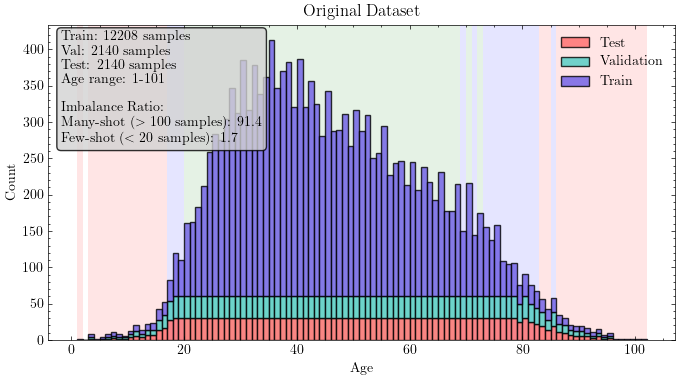

In [3]:
df = load_age_data(os.path.join('.', f"agedb.csv"))
df_train, df_val, df_test = df[df['split'] == 'train'], df[df['split'] == 'val'], df[df['split'] == 'test']
show_data_splits_stacked(df_train, df_val, df_test, df, use_science_plot=True, title="Original Dataset")

# Show Balanced Extrapolation Protocol

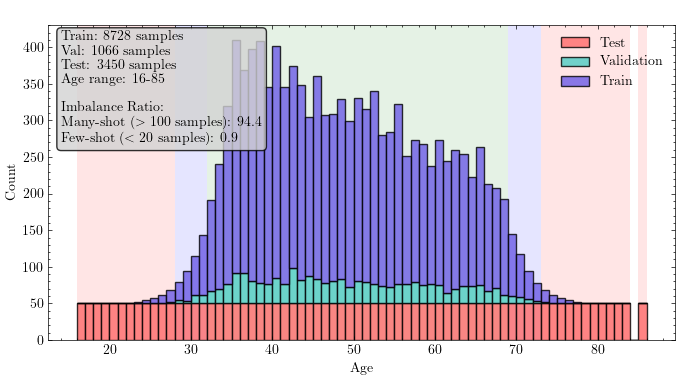

In [4]:
df_extra = load_age_data(os.path.join('.', f"agedb_extrapolation.csv"))
df_train_extra, df_val_extra, df_test_extra = df_extra[df_extra['split'] == 'train'], df_extra[df_extra['split'] == 'val'], df_extra[df_extra['split'] == 'test']
show_data_splits_stacked(df_train_extra, df_val_extra, df_test_extra, df_extra, use_science_plot=True, title=" ")

# Show Interpolation Protocol

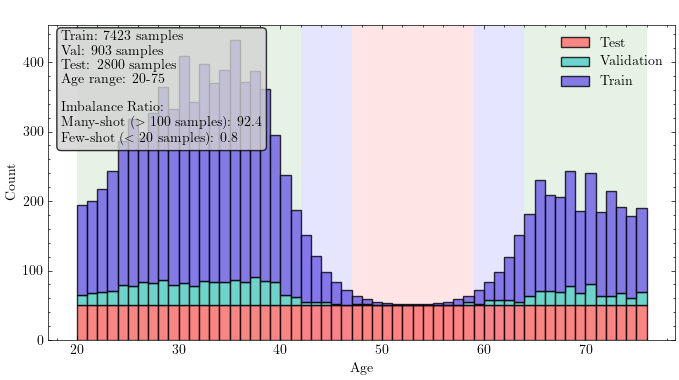

In [5]:
df_inter = load_age_data(os.path.join('.', f"agedb_interpolation.csv"))
df_train_inter, df_val_inter, df_test_inter = df_inter[df_inter['split'] == 'train'], df_inter[df_inter['split'] == 'val'], df_inter[df_inter['split'] == 'test']
show_data_splits_stacked(df_train_inter, df_val_inter, df_test_inter, df_inter, use_science_plot=True, title=" ")

# Show Blindspot Protocol

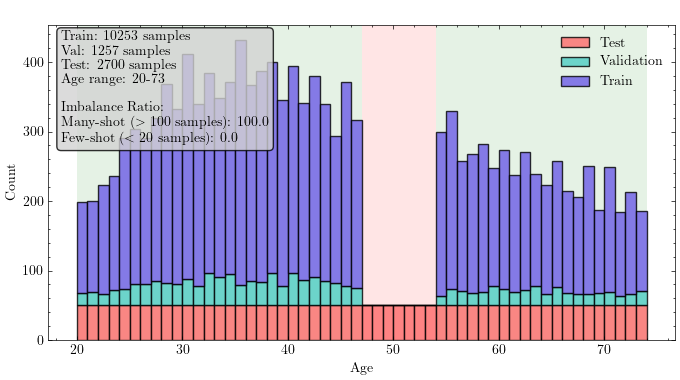

In [6]:
df_blind = load_age_data(os.path.join('.', f"agedb_blindspot.csv"))
df_train_blind, df_val_blind, df_test_blind = df_blind[df_blind['split'] == 'train'], df_blind[df_blind['split'] == 'val'], df_blind[df_blind['split'] == 'test']
show_data_splits_stacked(df_train_blind, df_val_blind, df_test_blind, df_blind, use_science_plot=True, title=" ")